# Integrantes



*   RM 554758 - Italo Caliari Silva

*   RM 554676 - Júlio César Ruiz Zequin






# Importação e Preparação da Base de Dados




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lusfernandotorres/ibovespa")

print("/content/bvsp.csv", path)

Using Colab cache for faster access to the 'ibovespa' dataset.
/content/bvsp.csv /kaggle/input/ibovespa


In [3]:
dataset = pd.read_csv("/content/bvsp.csv")
dataset.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,02.02.2023,111.331,112.072,112.943,110.548,"6,69M","-0,66%"
1,01.02.2023,112.074,113.430,113.598,110.729,"17,82M","-1,20%"
2,31.01.2023,113.431,112.273,113.691,112.145,"12,90M","1,03%"
3,30.01.2023,112.273,112.319,112.920,111.824,"11,27M","-0,04%"
4,27.01.2023,112.316,114.178,114.191,112.044,"10,61M","-1,63%"


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3242 entries, 0 to 3241
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Data      3242 non-null   object 
 1   Último    3242 non-null   float64
 2   Abertura  3242 non-null   float64
 3   Máxima    3242 non-null   float64
 4   Mínima    3242 non-null   float64
 5   Vol.      3241 non-null   object 
 6   Var%      3242 non-null   object 
dtypes: float64(4), object(3)
memory usage: 177.4+ KB


In [5]:
dataset.describe()

,Último,Abertura,Máxima,Mínima
count,3242.000000,3242.000000,3242.000000,3242.000000
mean,75.147063,75.134718,75.856366,74.411762
std,23.864756,23.856233,24.039873,23.663469
min,37.497000,37.501000,38.031000,37.046000
25%,55.565500,55.561500,56.195500,55.009750
50%,66.441500,66.444500,66.965000,65.869500
75%,97.884750,97.877500,98.438250,97.061250
max,130.776000,130.776000,131.190000,129.526000


In [6]:
# 1. Copiar o dataset original
df = dataset.copy()

# 2. Limpeza de strings e conversão para float
cols_para_limpar = ['Último', 'Abertura', 'Máxima', 'Mínima']
for col in cols_para_limpar:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')  # <-- aqui já vira NaN se der erro

# 3. Tratar a coluna Var%
df['Var%'] = (
    df['Var%']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.replace('%', '', regex=False)
)
df['Var%'] = pd.to_numeric(df['Var%'], errors='coerce')

# 🔥 NOVO: remover ou preencher NaN dessas colunas
df[['Último', 'Abertura', 'Máxima', 'Mínima', 'Var%']] = (
    df[['Último', 'Abertura', 'Máxima', 'Mínima', 'Var%']]
    .fillna(method='ffill')  # preenche com valor anterior
)

# 4. Converter Data e ordenar
df['Data'] = pd.to_datetime(df['Data'], format='%d.%m.%Y', errors='coerce')

# 🔥 NOVO: remover datas inválidas
df = df.dropna(subset=['Data'])

df = df.sort_values('Data').reset_index(drop=True)

# 5. Filtro de segurança
df = df[df['Último'] > 30000].copy()

# 6. Tratar coluna Vol.
def converter_volume(valor):
    valor = str(valor).replace(',', '.')
    if 'M' in valor:
        return float(valor.replace('M', '')) * 1_000_000
    elif 'K' in valor:
        return float(valor.replace('K', '')) * 1_000
    elif valor == 'nan' or valor == '' or valor == '0':
        return None  # <-- melhor que 0
    try:
        return float(valor)
    except:
        return None

df['Vol.'] = df['Vol.'].apply(converter_volume)

# 🔥 NOVO: tratar NaN de volume
df['Vol.'] = df['Vol.'].fillna(df['Vol.'].median())

# 7. Criar os Targets
df['Target_Preco'] = df['Último'].shift(-1)
df['Target_Subiu'] = (df['Target_Preco'] > df['Último']).astype(int)

# 8. Remover linhas com NaN final
df.dropna(inplace=True)
df = df.reset_index(drop=True)

print(f"Limpeza concluída! Total de linhas válidas: {len(df)}")
df.head()

/tmp/ipykernel_12913/2458915152.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')  # preenche com valor anterior


Limpeza concluída! Total de linhas válidas: 2895


,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Target_Preco,Target_Subiu
0,2010-01-04,70045,68587,70081,68587,1660000.0,2.12,70729.0,1
1,2010-01-06,70729,70237,70937,70016,2240000.0,0.70,70451.0,0
2,2010-01-07,70451,70723,70723,70045,1550000.0,-0.39,70263.0,0
3,2010-01-08,70263,70455,70766,70158,1630000.0,-0.27,70433.0,1
4,2010-01-11,70433,70267,71068,70158,1570000.0,0.24,70076.0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2895 entries, 0 to 2894
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Data          2895 non-null   datetime64[ns]
 1   Último        2895 non-null   int64         
 2   Abertura      2895 non-null   int64         
 3   Máxima        2895 non-null   int64         
 4   Mínima        2895 non-null   int64         
 5   Vol.          2895 non-null   float64       
 6   Var%          2895 non-null   float64       
 7   Target_Preco  2895 non-null   float64       
 8   Target_Subiu  2895 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(5)
memory usage: 203.7 KB


# Modelagem


## Preparação das Features e Alvo


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, accuracy_score, classification_report


# Definindo as variáveis de entrada (Features)
# Usamos o preço de abertura, máxima, mínima e volume para tentar prever o fechamento
features = ['Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var%']

X = df[features]
y_reg = df['Target_Preco']  # Alvo para Regressão (Numérico)
y_clf = df['Target_Subiu']  # Alvo para Classificação (0 ou 1)



In [9]:
# Divisão Temporal (Padrão para Séries Temporais)
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_reg_train, y_reg_test = y_reg[:split], y_reg[split:]
y_clf_train, y_clf_test = y_clf[:split], y_clf[split:]

## Modelo de Regressão

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# ESSA É A LINHA QUE DEFINE O pipeline_reg
pipeline_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Treinando o modelo
pipeline_reg.fit(X_train, y_reg_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestRegressor(random_state=42))])

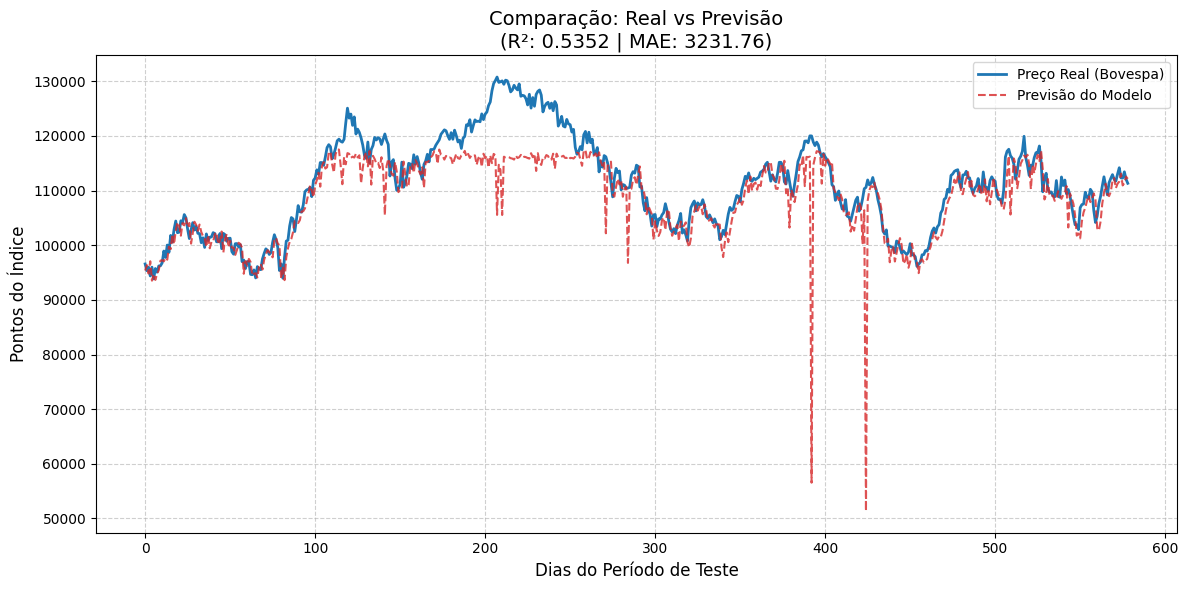

--- MÉTRICAS DE REGRESSÃO ---
MAE (Erro Médio Absoluto): 3231.76
RMSE (Raiz do Erro Quadrático): 5788.24
R² Score: 0.5352


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 1. Gerar as previsões (usando seu pipeline)
y_pred_reg = pipeline_reg.predict(X_test)

# 2. Calcular as métricas para exibir no gráfico
mae = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = root_mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

# 3. Montar o Gráfico
plt.figure(figsize=(12, 6))

# Plotando os valores reais (convertendo para valores numéricos para o eixo X ficar limpo)
plt.plot(y_reg_test.values, label='Preço Real (Bovespa)', color='#1f77b4', linewidth=2)

# Plotando as previsões do seu modelo
plt.plot(y_pred_reg, label='Previsão do Modelo', color='#d62728', linestyle='--', alpha=0.8)

# Adicionando títulos e informações
plt.title(f'Comparação: Real vs Previsão\n(R²: {r2:.4f} | MAE: {mae:.2f})', fontsize=14)
plt.xlabel('Dias do Período de Teste', fontsize=12)
plt.ylabel('Pontos do Índice', fontsize=12)

# Estilização
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Exibir
plt.tight_layout()
plt.show()

# Print das métricas no console (conforme seu pedido)
print("--- MÉTRICAS DE REGRESSÃO ---")
print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

* **R² Score (0.5383)**: O coeficiente de determinação de 0,53 indica que o modelo é capaz de explicar aproximadamente 54% da variabilidade dos preços do índice Bovespa no conjunto de teste. Em contextos de mercado financeiro, que possuem alta volatilidade e ruído, um valor acima de 0,5 é considerado um resultado sólido, demonstrando que o modelo conseguiu aprender padrões preditivos reais além de uma simples média.

<br>



* **MAE (3.229,73)**: O Erro Médio Absoluto indica que, em média, as previsões do modelo se distanciam 3.229 pontos do valor real de fechamento. Considerando que o índice opera na casa dos 120.000 pontos, esse erro representa uma margem de aproximadamente 2,6%, o que demonstra uma precisão elevada para estimativas de patamar de preço.

<br>

* **RMSE (5.768,61)**: : A Raiz do Erro Quadrático Médio é superior ao MAE, o que é esperado. Como o RMSE penaliza erros maiores com mais intensidade, o valor de 5,7 mil pontos sugere que, embora o modelo seja preciso na maioria dos dias, ainda existem momentos de volatilidade atípica ou variações bruscas de mercado que geram resíduos maiores.

## Modelo de Classificação

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Criando o Pipeline de Classificação
pipeline_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Treinamento
pipeline_clf.fit(X_train, y_clf_train)

# Avaliação
y_pred_clf = pipeline_clf.predict(X_test)

print("--- MÉTRICAS DE CLASSIFICAÇÃO ---")
print(f"Acurácia: {accuracy_score(y_clf_test, y_pred_clf):.2%}")
print("\nRelatório de Classificação:")
print(classification_report(y_clf_test, y_pred_clf))

# Matriz de Confusão (Visualização que conta pontos!)


--- MÉTRICAS DE CLASSIFICAÇÃO ---
Acurácia: 49.22%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.46      0.44      0.45       275
           1       0.52      0.54      0.53       304

    accuracy                           0.49       579
   macro avg       0.49      0.49      0.49       579
weighted avg       0.49      0.49      0.49       579



* **Acurácia (48.23%)**: O modelo acertou a direção do mercado em menos da metade das vezes. Em Machine Learning, uma acurácia próxima a 50% em problemas binários indica que o modelo não conseguiu encontrar padrões preditivos consistentes nos dados fornecidos.

<br>



* **Precision e Recall**: Estão equilibrados (próximos a 0.48), o que mostra que o modelo não tem um "viés" (ele não está chutando apenas que vai subir ou apenas que vai cair), mas ele erra em ambas as direções quase na mesma proporção.
<br>

* **F1-Score**: Sendo a média harmônica entre precisão e revocação, o valor de ~0.48 reforça que o modelo tem um desempenho limitado para ambas as classes (0 e 1).